# 官方推荐，使用stateless模式的场景
没有开启检查点，不需要状态，不需要保存检查点，也没有中断和多轮回话，只用于纯计算，无需追踪历史，

多数需要检查点， 但是之前多次调用子图可能造成混乱，就使用stateless

============================== -> 第一次运行结果 <- ==============================
{'input_texts': ['  LangGraph 真有意思 ', '  我喜欢 LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain']}
============================== -> 第二次运行结果 <- ==============================
{'input_texts': ['  Hello, LangGraph  ', '  Hello, LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain', 'LangGraph 真有意思', 'Hello, LangGraph', '我喜欢 LangChain', 'Hello, LangChain']}


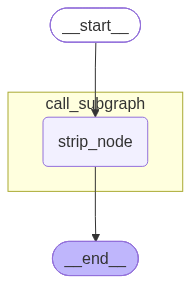

In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str
    clean_texts: Annotated[list[str], add]  # 字符串输出结果变成了列表

def strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    clean_text = raw_text.strip() # 去掉空格

    return {
        "clean_texts": [clean_text]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("strip_node", strip_node)
builder.add_edge(START, "strip_node")
builder.add_edge("strip_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile(checkpointer=False)  # Stateless：无检查点
subgraph = builder.compile(checkpointer=True)   # Per-thread：有状态（对比用）
# ==================================================

# 构建父图
class ParentState(TypedDict):
    input_texts: list[str]
    output_texts: Annotated[list[str], add]

def call_subgraph(state: ParentState) -> ParentState:
    input_texts = state["input_texts"]

    output_texts = []
    for input_text in input_texts: # 一个节点多次调用子图
        res = subgraph.invoke({"raw_text": input_text}) # 循环多次调用检查点
        output_texts += res["clean_texts"]

    return {
        "output_texts": output_texts # 然后结果合并 父节点保存状态，最终四句话
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "stateless-demo"}}

first_response = parent_graph.invoke(
    {
        "input_texts": ["  LangGraph 真有意思 ", "  我喜欢 LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "input_texts": ["  Hello, LangGraph  ", "  Hello, LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

# 下面有问题 应该输出4个，但是由于多次调用子图，导致  'LangGraph 真有意思', 'Hello, LangGraph', '我喜欢 LangChain' 第一个和第三个重复出现了
# 出现状态紊乱， 就是前面说的在一个节点多次调用同一个子图
# 因为检查点的信息基于超步，也基于节点进行保存，容易出现问题，
# 这个就是stateless场景，不需要进行重复的状态累积，需要每次调用感觉，不用累积历史

============================== -> 第一次运行结果 <- ==============================
{'input_texts': ['  LangGraph 真有意思 ', '  我喜欢 LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain']}
============================== -> 第二次运行结果 <- ==============================
{'input_texts': ['  Hello, LangGraph  ', '  Hello, LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain', 'Hello, LangGraph', 'Hello, LangChain']}


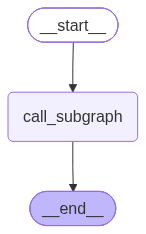

In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str
    clean_texts: Annotated[list[str], add]  # 字符串输出结果变成了列表

def strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    clean_text = raw_text.strip() # 去掉空格

    return {
        "clean_texts": [clean_text]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("strip_node", strip_node)
builder.add_edge(START, "strip_node")
builder.add_edge("strip_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
subgraph = builder.compile(checkpointer=False)  # Stateless：无检查点
# subgraph = builder.compile(checkpointer=True)   # Per-thread：有状态（对比用）
# ==================================================

# 构建父图
class ParentState(TypedDict):
    input_texts: list[str]
    output_texts: Annotated[list[str], add]

def call_subgraph(state: ParentState) -> ParentState:
    input_texts = state["input_texts"]

    output_texts = []
    for input_text in input_texts:
        res = subgraph.invoke({"raw_text": input_text}) # 循环多次调用检查点
        output_texts += res["clean_texts"]

    return {
        "output_texts": output_texts # 然后结果合并 父节点保存状态，最终四句话
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "stateless-demo"}}

first_response = parent_graph.invoke(
    {
        "input_texts": ["  LangGraph 真有意思 ", "  我喜欢 LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "input_texts": ["  Hello, LangGraph  ", "  Hello, LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

# outputs结果正常， 几次结果放在最后